# Environment Setup

## PIP

In [2]:
!pip install colour
!pip install matplotlib
!pip install pandas
!pip install utm
!pip install windrose




[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


## Imports

In [3]:

import math
import matplotlib.pyplot as plt
import matplotlib_inline
import numpy as np
import pandas as pd
import utm
from itertools import product
from collections import defaultdict
import io
import pandas as pd
import pickle
import matplotlib.patches as patches
import glob
import os
import datetime
import windrose
from copy import deepcopy
from columnTitles import column

Roll


## Functions

In [4]:
def windAnalysis(heading,windDirection, windSpeed):
    newWindDirections = []
    newWindSpeeds = []
    for i in range(0,windDirection.__len__()):
        if(windDirection[i] == 'nan' or heading[i] == 'NaN'):
            a = 1 
        elif(float(windDirection[i]) < 0):
            windScaled = 360+float(windDirection[i])
            windMagnetic = windScaled + float(heading[i])
            if(windMagnetic >= 360):
                windMagnetic = windMagnetic - 360
            newWindDirections.append(float(windMagnetic))
        elif(float(windDirection[i]) > 0):
            windMagnetic = float(windDirection[i]) +float(heading[i])
            if(windMagnetic >= 360):
                windMagnetic = windMagnetic - 360
            newWindDirections.append(float(windMagnetic))

    for i in range(0,windSpeed.__len__()):
        if(windSpeed[i] == 'nan'):
            a = 1 
        elif(float(windSpeed[i]) < 0):
            newWindSpeeds.append(float(windSpeed[i]))
        elif(float(windSpeed[i]) > 0):
            newWindSpeeds.append(float(windSpeed[i]))
        

    ## Calculate Average Wind Direction and Speed and put in a bin
    totalDirection = 0
    totalSpeed = 0
    for i in range(0,newWindDirections.__len__()):
        totalDirection += newWindDirections[i]

    for i in range(0,newWindSpeeds.__len__()):
        totalSpeed += float(newWindSpeeds[i])


    avgDirection = totalDirection/newWindDirections.__len__() 
    avgSpeed = totalSpeed/newWindSpeeds.__len__()
    if math.isnan(avgDirection):
        avgDirection = 0
    return [avgDirection,avgSpeed]

def windBins(dfArray):
    directionBins = [[] for _ in range(361)]
    speedBins = [[] for _ in range(50)]
    for i in range(0,90):
        currdf = dfArray[i]
        if (' WndDr' in currdf) and (' WndSpd' in currdf) and (' HDG' in currdf):
            averages = windAnalysis(currdf[' HDG'],currdf[' WndDr'],currdf[' WndSpd'])
            destinationBin = int(math.floor(averages[0]))
            speedBin = int(math.floor(averages[1]))
            # print(math.floor(averages[0]))
            # print(destinationBin, "--" , i,"speed",speedBin )
            directionBins[destinationBin].append(i)
            speedBins[speedBin].append(i)
    return (directionBins,speedBins)




def summaryStatistics(descent,summaryTarget:str,file,currFlight,descentNum):
    meanDescentRate = np.mean(pd.to_numeric(descent[summaryTarget]))
    medianDescentRate = np.median(pd.to_numeric(descent[summaryTarget]))
    stdDescentRate = np.std(pd.to_numeric(descent[summaryTarget]))
    maxDescentRate = np.max(pd.to_numeric(descent[summaryTarget]))
    minDescentRate = np.min(pd.to_numeric(descent[summaryTarget]))
    results = (float(meanDescentRate), float(medianDescentRate), float(stdDescentRate), float(maxDescentRate), float(minDescentRate))
    file.write("{}, {}, {},{},{},{},{}\n".format(currFlight,descentNum,results[0],results[1],results[2],results[3],results[4]))
    file.flush()


def distanceImageVelocity(descent, convert):

    if ' GndSpd' in descent and ' HDG' in descent:

        index = 0
        for i in range(len(descent)):
            if descent['AltAGL'][i] < 10:
                index = i
                break

        totalX_nm = 0.0
        totalY_nm = 0.0

        for i in range(0, index):

            s1 = float(descent[' GndSpd'][i])
            s2 = float(descent[' GndSpd'][i+1])

            if convert:
                s1 *= 1.94384
                s2 *= 1.94384

            avgS = (s1 + s2) / 2

            heading_deg = float(descent[' HDG'][i])
            heading_rad = math.radians(heading_deg)

            d_nm = avgS / 3600.0

            dx = d_nm * math.cos(heading_rad)
            dy = d_nm * math.sin(heading_rad)

            totalX_nm += dx
            totalY_nm += dy

        # Distance (magnitude)
        distance_nm = math.sqrt(totalX_nm**2 + totalY_nm**2)

        # Direction (bearing)
        bearing_rad = math.atan2(totalY_nm, totalX_nm)
        bearing_deg = (math.degrees(bearing_rad) + 360) % 360

        print("Distance:", distance_nm, "NM")
        print("Bearing:", bearing_deg, "deg")

        return [distance_nm, bearing_deg]
    

def utilizeModelData(useManual:bool = False):
    filePath = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/FollowCoords2--Turbulence Experiments 2026-02-14 14:10:32.404221"
    filePath2 = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/Roll1--Turbulence Experiments 2026-02-13 13:03:32.478263/1_Roll1--Turbulence Experiments.csv"
    filePath3 = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/RecTest1--Turbulence Experiments 2026-03-20 09:53:39.848992/{}_RecTest1--Turbulence Experiments.csv"
    filePath4 = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/RecTest2--Turbulence Experiments 2026-03-20 09:59:21.064022/{}_RecTest2--Turbulence Experiments.csv"
    filePath5 = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/RecTest3--Turbulence Experiments 2026-03-20 10:09:38.439818/{}_RecTest3--Turbulence Experiments.csv"
    filePath6 = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/RecTest4--Turbulence Experiments 2026-03-20 10:16:14.758129/{}_RecTest4--Turbulence Experiments.csv"
    showcaseRun = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/RecTest6--Turbulence Experiments 2026-03-20 10:32:46.050711/{}_RecTest6--Turbulence Experiments.csv"
    showcaseRun2= "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/RecTest7--Turbulence Experiments 2026-03-20 10:36:47.246532/{}_RecTest7--Turbulence Experiments.csv"
    comparisonRuns = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/ComparisonRuns--Turbulence Experiments 2026-03-13 17:00:07.067204/{}_ComparisonRuns--Turbulence Experiments.csv"
    ex2 = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/ex2--turbulence experiments 2026-04-13 01:20:57.181772/{}_ex2--turbulence experiments.csv"
    ex6 = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/Ex6--turbulence experiments 2026-04-13 13:00:40.017013/{}_Ex6--turbulence experiments.csv"
    combinedAnalysis = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/CombinedAnalysis--turbulence experiments 2026-06-05 10:05:24.166731/{}_CombinedAnalysis--turbulence experiments.csv"
    manualControl1 = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/ManualControl-1--turbulence experiments 2026-04-23 16:20:19.558488/{}_ManualControl-1--turbulence experiments.csv"
    modelData = [[]]
    for x in range (1,100):
        try:
            # data = pd.read_csv('/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/ComparisonRuns--Turbulence Experiments 2026-03-13 17:00:07.067204/{}_ComparisonRuns--Turbulence Experiments.csv'.format(x))
            # data = pd.read_csv(comparisonRuns.format(x))
            # data = pd.read_csv(showcaseRun.format(x))
            data = pd.read_csv(ex6.format(x))
            if (useManual):
                data = pd.read_csv(manualControl1.format(x))

            modelData[0].append(data)
        except FileNotFoundError:
            print("{} Files Loaded".format(x-1))
            return modelData
            break
        else:
            # Continue Loop
            continue


## Global Variables

In [5]:
directionBins = [[] for _ in range(361)]
speedBins = [[] for _ in range(50)]
colors =["red","green","blue","purple","orange","black","yellow","cyan","magenta","brown","pink","gray","olive","lime","teal","navy"]

# Analysis

In [6]:
aircraft = "Cessna_172S_flight_"
# index = 45
folder = "../../Project_Data/Empirical_Data/GATS_Dataset/"
fileType = ".csv"
dataArray = [] 
for index in range(1,20):
    df = pd.read_csv(f'{folder}{aircraft}{index}{fileType}')
    df.columns = df.columns.str.lstrip()
    dataArray.append(df)


for x in range(0,dataArray.__len__()):
    dataArray[x] = dataArray[x].iloc[-1000:].reset_index(drop=True)
# df = pd.read_csv(f'{folder}{aircraft}{index}{fileType}')
# df2 = pd.read_csv(f'{folder}{aircraft}{index+1}{fileType}')
# df3= pd.read_csv(f'{folder}{aircraft}{index+2}{fileType}')

In [7]:
dataArray.__len__()

19

/var/folders/mg/0046pj397qn7zqxn7sxp4b_w0000gn/T/ipykernel_34386/393085353.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/var/folders/mg/0046pj397qn7zqxn7sxp4b_w0000gn/T/ipykernel_34386/393085353.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


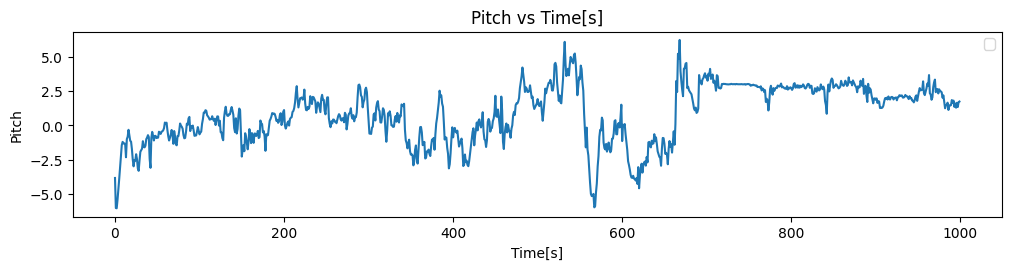

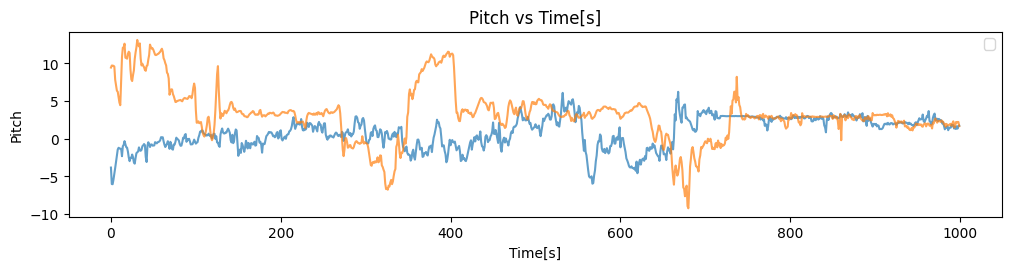

TypeError: can only concatenate str (not "bool") to str

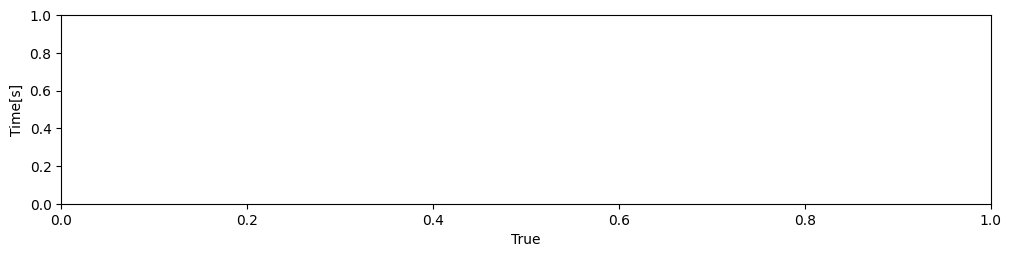

In [ ]:
backgroundAlpha = 0.2
foregroundAlpha = 0.7
# def calculateAverageLine(dataframeArray,column):
#     maxLength = 0
#     for df in dataframeArray:
#         if df.__len__() > maxLength:
#             maxLength = df.__len__()
#     averageLine = np.zeros(maxLength)
#     for x in range(0,maxLength):
#         for df in dataframeArray:
#             if x < df.__len__():
#                 averageLine[x] += df[column].iloc[x]
#         averageLine[x] = averageLine[x]/dataframeArray.__len__()
#     return averageLine

def calculateAverageLine(dataframeArray, column):
    combined = pd.concat(
        [df[column] for df in dataframeArray],
        axis=1
    )
    # print(combined.loc[-5:5])
    
    return combined.mean(axis=1).sort_index()

def singlePlot(dataframe,column,xlabel):
    plt.figure(layout='constrained',figsize=(10, 10))
    ax = plt.subplot(5,1,1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(column)
    ax.set_title(column + " vs " + xlabel)
    plt.legend()
    plt.plot(dataframe[column])



def withinGroupPlot(dataframeArray,column,xlabel,showAverageLine:bool = False):
    if(dataframeArray.__len__() <=0):
        print("Nothing to Plot")
        return
    plt.figure(layout='constrained',figsize=(10, 10))
    ax = plt.subplot(5,1,1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(column)
    ax.set_title(column + " vs " + xlabel)
    alphaValue = backgroundAlpha if showAverageLine else foregroundAlpha
    for df in dataframeArray:
        plt.plot(df[column],alpha=alphaValue)
    if showAverageLine:
        averageLine = calculateAverageLine(dataframeArray,column)
        plt.plot(averageLine.index, averageLine.values, color = 'black', linewidth=1, label='Average Line')
    plt.legend()
    plt.show()

def betweenGroupPlot(groupArray,groupTitles,column,xlabel,showAverageLine:bool = False):
    if(groupArray.__len__() <=0):
        print("Nothing to Plot")
        return

    plt.figure(layout='constrained',figsize=(20, 20))
    ax = plt.subplot(5,1,1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(column)
    ax.set_title(column + " vs " + xlabel)
    index = 0
    alphaValue = backgroundAlpha if showAverageLine else foregroundAlpha
    for group in groupArray:
        if(group.__len__() <=0):
            print("Nothing to Plot")
            return
        for df in group:
          plt.plot(df[column], color = 'C{i}'.format(i=index),alpha=0.2)
        if showAverageLine:
            averageLine = calculateAverageLine(group,column)
            plt.plot(averageLine.index, averageLine.values, color = 'C{i}'.format(i=index), linewidth=1, label=groupTitles[index] + " " + column+ ' Average')
        index += 1
    plt.legend()
    plt.show()

singlePlot(dataArray[0],column.Pitch,"Time[s]")
withinGroupPlot(dataArray[0:2],column.Pitch,"Time[s]",False)
# betweenGroupPlot([[dataArray[0], dataArray[1]],[dataArray[2],dataArray[3]]],column.Pitch,"Time[s]",True)
# betweenGroupPlot([[dataArray[0], dataArray[1]],[dataArray[2],dataArray[3]]],column.Roll,"Time[s]",True)
# betweenGroupPlot([[dataArray[0], dataArray[1]],[dataArray[2],dataArray[3]]],column.Altitude_AGL,"Time[s]",True)